### Introdução a processamento de sinais
---
Os sinais que geralmente encontramos na natureza são sinais analógicos e em tempo contínuo, esses sinais são representações fisícas que por conveniência podemos querer representar em sinais elétricos (digitais). Para pocessar esse sinal digitalmente precisamos converter esse sinal para um formato digital, conversão A/D.

+ __Amostragem:__ Processo de aquisição de amostras para ter uma maior precisão no formato da onda a ser estudada. A amostragem converte um sinal analógico em uma série de impulsos.

O teorema de Nyquist nos diz que para um sinal digital ser funcionalmente igual ao sinal analógico original, a frequência da amostragem precisa ser no mínimo duas vezes maior que a frequência do sinal analógico.

+ __Conversão:__ Converte a saída da amostragem e a retenção de uma série de códigos binários que representam a amplitude do sinal analógico.

+ __Quantização:__ Onde é convertido cada valor da amostragem do sinal analógico em um conjunto de valores discretos, ou seja, em código bináro. Quanto maior for os números de bits, mais precisa será a representação.

> __Conversão A/D:__
> + __Número de bits:__ $Nb = 4$
> + __Calcular o Passo de Quantização:__ $k = \frac{V_pp}{2^{Nb}}$
> + __Valor Quantizado:__ $vq = \frac{Sinal}{k}$

In [38]:
import sympy as sp
import numpy as np
import scipy.signal as signal
import scipy.fft
import matplotlib.pyplot as plt

def biquant(nb, vp_min, vp_max, x):

    L = 2**nb
    k = (vp_max - vp_min)/L

    vq = round((x - vp_min)/k)
    xq = vp_min + vq*k
    #xq = round((x/k)*k)

    return xq

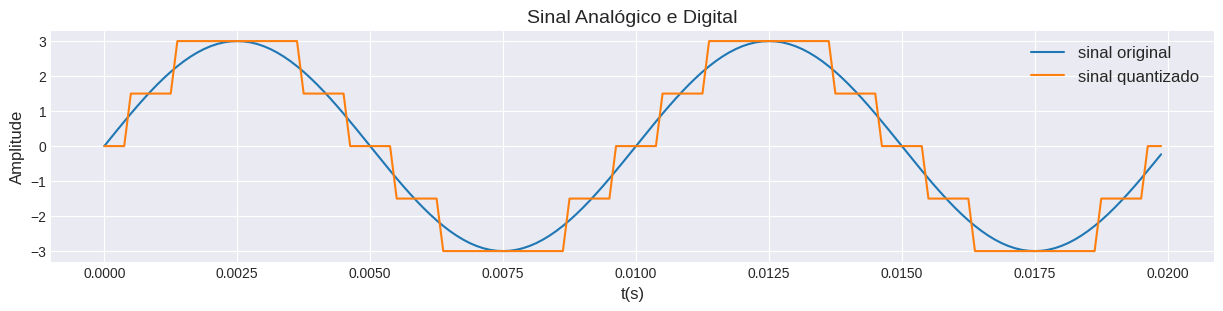

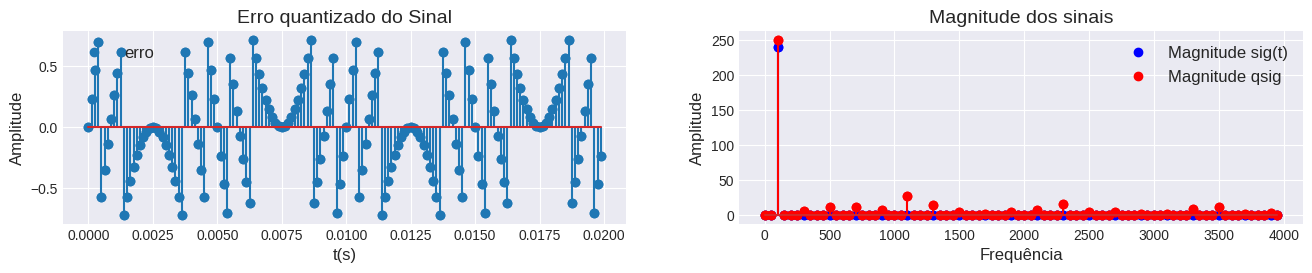

In [86]:
tx = 8000
T = 1/tx

t = np.arange(0, 0.02, T)
sig = lambda t: 3 * np.sin(2 * np.pi * 100 * t)

qsig = list()
bits = 2
for i in range(len(t)):
    qsig.append(biquant(bits, -3, 3, sig(t[i])))

# Calculando o erro.
erro = sig(t) - qsig

# Fazendo a transformada de Fourier
sig_fft = scipy.fft.fft(sig(t))
freq = scipy.fft.fftfreq(len(t), T)

qsig_fft = scipy.fft.fft(qsig)

# Configurando os gráficos.
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(15, 3))
plt.plot(t, sig(t), label='sinal original')
plt.plot(t, qsig, label='sinal quantizado')
plt.xlabel('t(s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Sinal Analógico e Digital', fontsize=14)
plt.legend(fontsize=12)


fig, axis = plt.subplots(1, 2, figsize = (16,2.5))

axis[0].plot(t, erro, "o", label='erro')
axis[0].stem(t, erro)
axis[0].set_xlabel('t(s)', fontsize=12)
axis[0].set_ylabel('Amplitude', fontsize=12)
axis[0].set_title('Erro quantizado do Sinal', fontsize=14)
axis[0].legend(fontsize=12)

axis[1].plot(freq[:len(t)//2], np.abs(sig_fft[:len(t)//2]), "o", color = "blue", label='Magnitude sig(t)')
axis[1].stem(freq[:len(t)//2], np.abs(sig_fft[:len(t)//2]), linefmt='b-', markerfmt='bo')
axis[1].plot(freq[:len(t)//2], np.abs(qsig_fft[:len(t)//2]), "o", color = "red", label='Magnitude qsig')
axis[1].stem(freq[:len(t)//2], np.abs(qsig_fft[:len(t)//2]), linefmt='r-', markerfmt='ro')
axis[1].set_xlabel('Frequência', fontsize=12)
axis[1].set_ylabel('Amplitude', fontsize=12)
axis[1].set_title('Magnitude dos sinais', fontsize=14)
axis[1].legend(fontsize=12)

plt.show()

### Relação sinal ruído

No processo de quantização o sinal de amostragem pode perder seu valor em relação ao valor de amplitude do sinal original dependendo da quantidade de bits que escolhemos, assim sendo representado por seu valor arredondado, por isso que usamos a função `round`.

A relação sinal ruído __(SNR)__ é defenido como a razão da potência do sinal original e a potência do erro quantizado, expressa geralmente em decibeis (dB).
$$SNR_{db} = 10log_{10}(\frac{P_s}{P_e}) = 20log_{10}(\frac{RMS_s}{RMS_e})$$
A potência é o valor de RMS elevado ao quadrado.

In [88]:
def x(rms):
  sum = 0
  for i in range(len(rms)):
    sum += rms[i]**2
  return sum

for i in range(len(erro)):
    if erro[i] < -1 or erro[i] >= 1:
        print('Erro muito grande, tente aumentar o número de bits!')

pot_sig = x(sig(t))
pot_erro = x(erro)

snr_db = 10*np.log10(pot_sig/pot_erro)
print("O valor de SNR em dB:", snr_db)

O valor de SNR em dB: 14.590353893822028


### Referências
---
1. **Juan**. *conceito amostragem e quantização*. Disponível em: [https://www.youtube.com/watch?v=5jpacFCD34k](https://www.youtube.com/watch?v=5jpacFCD34k). Acessado em: 31 de outubro de 2024
2. **Leandro Manso**. *Efeito do Erro de Quantização dos ADCs*. Disponível em: [https://www.youtube.com/watch?v=uwtjkeb9Mk8](https://www.youtube.com/watch?v=uwtjkeb9Mk8). Acessado em: 31 de outubro de 2024